In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
df = pd.read_csv("C:\\Users\\libin_urv2w13\\Desktop\\mljourney\\Supervised-ML\\Classification\\exam\\heart\\heart_failure_clinical_records_dataset.csv (1).xls")

In [185]:
df[df.duplicated()]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT


In [186]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

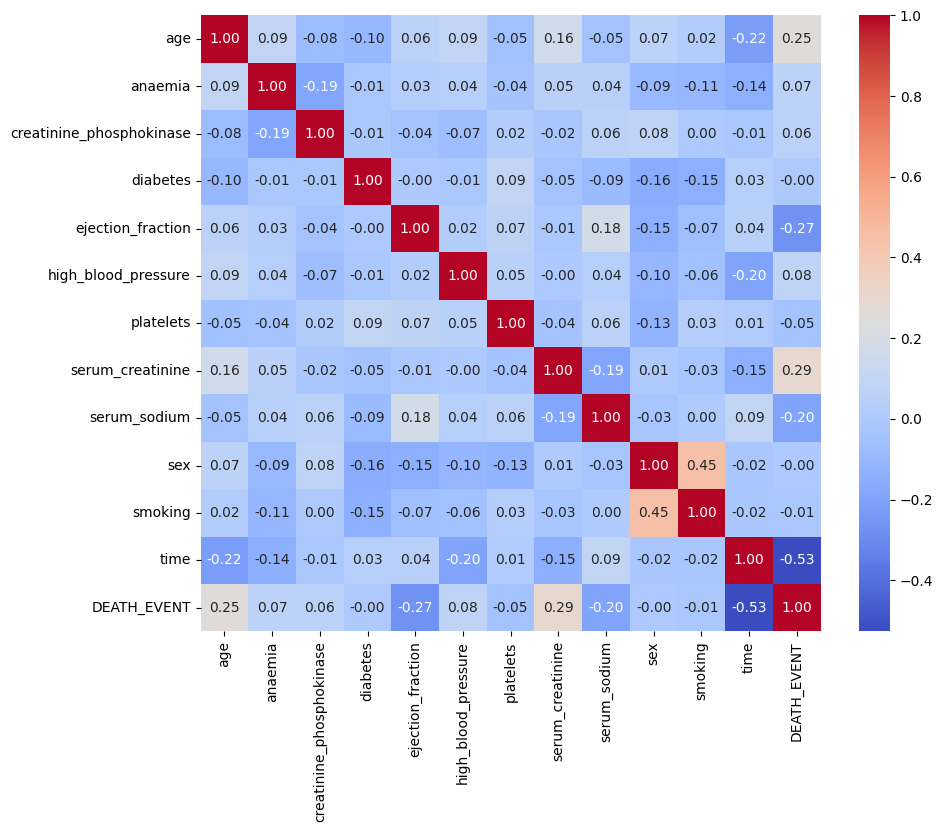

In [187]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [188]:
x = df[["age","ejection_fraction","serum_creatinine","serum_sodium","time"]]
y = df["DEATH_EVENT"]

In [189]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=4)

In [190]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [191]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(accuracy_score(y_test,y_pred)*100)
print(f1_score(y_test,y_pred)*100)
print(precision_score(y_test,y_pred)*100)
print(recall_score(y_test,y_pred)*100)

83.33333333333334
70.58823529411765
75.0
66.66666666666666


In [192]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(accuracy_score(y_test,y_pred)*100)
print(f1_score(y_test,y_pred)*100)
print(precision_score(y_test,y_pred)*100)
print(recall_score(y_test,y_pred)*100)

85.0
74.28571428571429
76.47058823529412
72.22222222222221


In [193]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(accuracy_score(y_test,y_pred)*100)
print(f1_score(y_test,y_pred)*100)
print(precision_score(y_test,y_pred)*100)
print(recall_score(y_test,y_pred)*100)

88.33333333333333
80.0
82.35294117647058
77.77777777777779


In [194]:
x.head(3)

,age,ejection_fraction,serum_creatinine,serum_sodium,time
0,75.0,20,1.9,130,4
1,55.0,38,1.1,136,6
2,65.0,20,1.3,129,7


In [195]:
y.head(3)

0    1
1    1
2    1
Name: DEATH_EVENT, dtype: int64

In [196]:
new_patient = [[75,20,1.9,130,4]]
result = rf.predict(scaler.transform(new_patient))[0]
heart_disease_map = {0:"survival",1:"non_survival"}
print(heart_disease_map.get(result))


non_survival


c:\Users\libin_urv2w13\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [197]:
import joblib
joblib.dump(dt,"model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']